In [1]:
import math
import time
import numpy as np
import torch
import matplotlib.pyplot as plt
import torch.nn as nn
import gzip
import csv
from torch.nn.utils.rnn import pack_padded_sequence
from torch.utils.data import Dataset, DataLoader

In [2]:
# Parameters
HIDDEN_SIZE = 100
BATCH_SIZE = 256
N_LAYER = 2
N_EPOCHS = 100
N_CHARS = 128
USE_GPU = True

In [3]:
# Prepare Data
class NameDataset(Dataset):
    def __init__(self, is_train_set=True):
        filename = 'data/names_train.csv.gz' if is_train_set else 'data/names_test.csv.gz'
        with gzip.open(filename, 'rt') as f:
            reader = csv.reader(f)
            rows = list(reader)
        self.names = [row[0] for row in rows]
        self.len = len(self.names)
        self.countries = [row[1] for row in rows]
        self.country_list = list(sorted(set(self.countries)))
        self.country_dict = self.getCountryDict()
        self.country_num = len(self.country_list)
        
    def __getitem__(self, index):
        return self.names[index], self.country_dict[self.countries[index]]
    
    def __len__(self):
        return self.len
    
    def getCountryDict(self):
        country_dict = dict()
        for idx, country_name in enumerate(self.country_list, 0):
            country_dict[country_name] = idx
        return country_dict
    
    # Return country name giving index
    def idx2country(self, index):
        return self.country_list[index]
    
    # Return the number of countries
    def getCountriesNum(self):
        return self.country_num

In [4]:
# Prepare Dataset and DataLoader
trainset = NameDataset(is_train_set=True)
trainloader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)
testset = NameDataset(is_train_set=False)
testloader = DataLoader(testset, batch_size=BATCH_SIZE, shuffle=False)

# N_COUNTRY is the output size of our model
N_COUNTRY = trainset.getCountriesNum()

In [5]:
# Model Design
class RNNClassifier(torch.nn.Module):
    def __init__(self, input_size, hidden_size, output_size, n_layers=1, bidirectional=True):
        super(RNNClassifier, self).__init__()
        self.hidden_size = hidden_size
        self.n_layers = n_layers
        self.n_directions = 2 if bidirectional else 1
        
        # The input of Embedding Layer with shape: (seqLen, batchSize)
        # The output of Embedding Layer with shape: (seqLen, batchSize, hiddenSize)
        self.embedding = torch.nn.Embedding(input_size, hidden_size)
        
        # The inputs of GRU Layer with shape: 
        # input: (seqLen, batchSize, hiddenSize)
        # hidden: (nLayers * nDirections, batchSize, hiddenSize)
        # The outputs of GRU Layer with shape:
        # output: (seqLen, batchSize, hiddenSize * nDirections)
        # hidden: (nLayers * nDirections, batchSize, hiddenSize)
        self.gru = torch.nn.GRU(hidden_size, hidden_size, n_layers, bidirectional=bidirectional)
        self.fc = torch.nn.Linear(hidden_size * self.n_directions, output_size)
        
    def __init_hidden(self, batch_size):
        hidden = torch.zeros(self.n_layers * self.n_directions, batch_size, self.hidden_size)
        return create_tensor(hidden)
    
    def forward(self, input, seq_lengths):
        # input shape: B x S -> S x B
        input = input.t()
        batch_size = input.size(1)
        
        hidden = self.__init_hidden(batch_size)
        # Result of embedding with shape: (seqLen, batchSize, hiddenSize)
        embedding = self.embedding(input)
        
        # pack them up
        gru_input = pack_padded_sequence(embedding, seq_lengths.cpu(), enforce_sorted=False)
        
        output, hidden = self.gru(gru_input, hidden)
        if self.n_directions == 2:
            hidden_cat = torch.cat([hidden[-1], hidden[-2]], dim=1)
        else:
            hidden_cat = hidden[-1]
        fc_output = self.fc(hidden_cat)
        return fc_output

In [6]:
# Convert name to tensor
def make_tensors(names, countries):
    sequences_and_lengths = [name2list(name) for name in names]
    name_sequences = [s1[0] for s1 in sequences_and_lengths]
    seq_lengths = torch.LongTensor([s1[1] for s1 in sequences_and_lengths])
    countries = countries.long()
    
    # make tensor of name, BatchSize x SeqLen
    seq_tensor = torch.zeros(len(name_sequences), seq_lengths.max()).long()
    for idx, (seq, seq_len) in enumerate(zip(name_sequences, seq_lengths), 0):
        seq_tensor[idx, :seq_len] = torch.LongTensor(seq)
        
    # sort by length to use pack_padded_sequence
    seq_lengths, perm_idx = seq_lengths.sort(dim=0, descending=True)
    seq_tensor = seq_tensor[perm_idx]
    countries = countries[perm_idx]
    
    return create_tensor(seq_tensor), create_tensor(seq_lengths), create_tensor(countries)

In [7]:
def name2list(name):
    arr = [ord(c) for c in name]
    return arr, len(arr)

In [8]:
def create_tensor(tensor):
    if USE_GPU:
        device = torch.device("cuda:0")
        tensor = tensor.to(device)
    return tensor

In [9]:
# One Epoch Training
def trainModel():
    total_loss = 0
    for i, (names, countries) in enumerate(trainloader, 1):
        inputs, seq_lengths, target = make_tensors(names, countries)
        output = classifier(inputs, seq_lengths)
        loss = criterion(output, target)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        
        total_loss += loss.item()
#         if i % 10 == 0:
#             print(f'[{time_since(start)}] Epoch {epoch} ', end='')
#             print(f'[{i * len(inputs)}/{len(trainset)}]', end='')
#             print(f'loss={total_loss / (i * len(inputs))}')
    return total_loss

In [10]:
# Testing
def testModel():
    correct = 0
    total = len(testset)
#     print("evaluating trained model ...")
    with torch.no_grad():
        for i, (names, countries) in enumerate(testloader, 1):
            inputs, seq_lengths, target = make_tensors(names, countries)
            output = classifier(inputs, seq_lengths)
            pred = output.max(dim=1, keepdim=True)[1]
            correct += pred.eq(target.view_as(pred)).sum().item()
            
        percent = '%.2f' % (100 * correct / total)
#         print(f'Test set: Accuracy {correct}/{total} {percent}%')
        
    return correct / total

In [11]:
def time_since(since):
    s = time.time() - since
    m = math.floor(s / 60)
    s -= m * 60
    return "{}m {:.0f}s".format(m, s)

In [12]:
classifier = RNNClassifier(N_CHARS, HIDDEN_SIZE, N_COUNTRY, N_LAYER)
if USE_GPU:
    device = torch.device("cuda:0")
    classifier.to(device)

# Loss and Optimizer
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(classifier.parameters(), lr=0.001)

# Time
start = time.time()
# print("Training for {} epochs...".format(N_EPOCHS))
acc_list = []
for epoch in range(1, N_EPOCHS + 1):
    # Train cycle
    trainModel()
    # Test
    acc = testModel()
    acc_list.append(acc)
#     print('acc_list: ', acc_list)

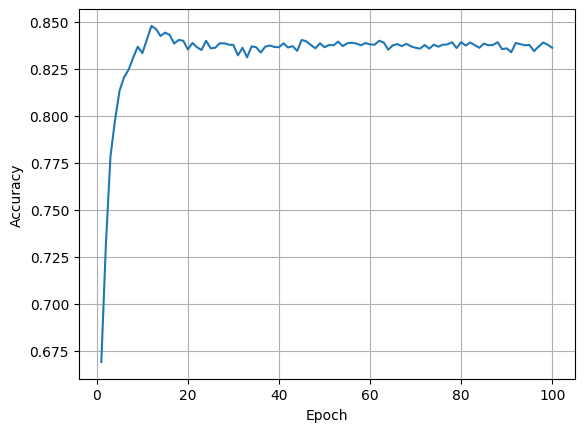

In [13]:
epoch = np.arange(1, len(acc_list) + 1)
acc_list = np.array(acc_list)
plt.plot(epoch, acc_list)
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.grid()
plt.show()